# Signal Processing Project
## Q2


This notebook implements the template-matching / correlation-based arrhythmia detector described in the
problem, walks through the reasoning for each conceptual sub-question, and runs the detector on the
provided recording (`patient_ecg.npy`, `template.npy`).

All numerical results below are computed directly from the provided dataset, not assumed.

## Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import find_peaks

ecg = np.load('patient_ecg.npy')
template = np.load('template.npy')
fs = 250  # Hz

print(f"ecg: shape={ecg.shape}, dtype={ecg.dtype}")
print(f"template: shape={template.shape}, dtype={template.dtype}")

ecg: shape=(5000,), dtype=float64
template: shape=(200,), dtype=float64


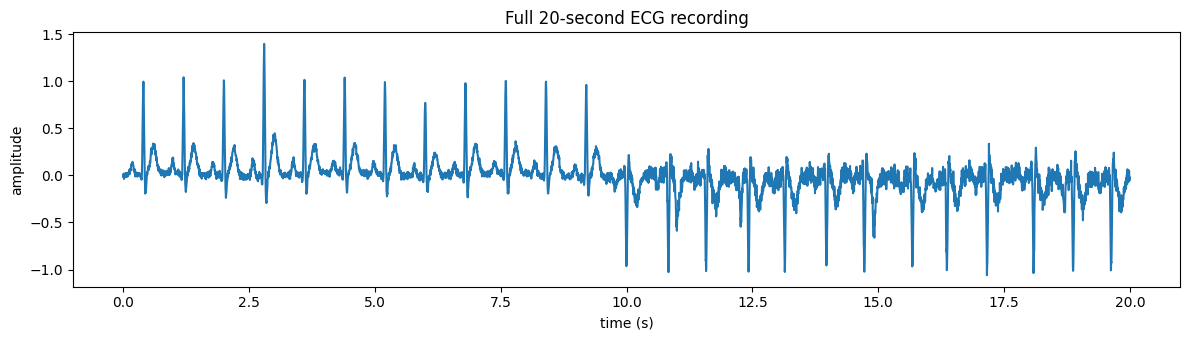

In [ ]:
plt.figure(figsize=(12,3.5))
plt.plot(np.arange(len(ecg))/fs, ecg)
plt.xlabel('time (s)'); plt.ylabel('amplitude')
plt.title('Full 20-second ECG recording')
plt.tight_layout()
plt.show()

## Part (a): Reading the signal

**(i) Clip length.** duration $= N/f_s = 5000/250 = 20$ s.

**(ii) Heart rate & samples/beat.** In the healthy stretch one beat repeats every $T = 0.8$ s, so
heart rate $= 60/T = 60/0.8 = 75$ bpm. One beat occupies $T \cdot f_s = 0.8 \times 250 = 200$ samples.

**(iii) Fundamental frequency.** Treating the healthy ECG as periodic with period $T=0.8$ s,
$f_0 = 1/T = 1/0.8 = 1.25$ Hz.

In [ ]:
N = len(ecg)
duration = N / fs
beat_period = 0.8                       # s, given
bpm = 60 / beat_period
samples_per_beat = int(beat_period * fs)
f0 = 1 / beat_period

print(f"duration            = {duration} s")
print(f"heart rate          = {bpm} bpm")
print(f"samples per beat    = {samples_per_beat}")
print(f"fundamental f0      = {f0} Hz")

duration            = 20.0 s
heart rate          = 75.0 bpm
samples per beat    = 200
fundamental f0      = 1.25 Hz


## Part (b): Healthy heart in frequency domain

**(i) Shape of |X(f)|.** A signal that is (nearly) periodic has a magnitude spectrum that is **not** a
smooth continuous curve — it is a *line (comb) spectrum*: discrete spikes at $f_0$ and its harmonics
$2f_0, 3f_0, \dots$, with heights set by the Fourier-series envelope of one beat. We verify this below
by taking the FFT of the healthy stretch (first 9.6 s, 12 beats) of the real recording.

**(ii) High-frequency content.** The **QRS spike** is responsible for the high-frequency content. A
sharp, narrow time-domain feature has energy spread over a wide range of frequencies (time-bandwidth
duality) — the more abruptly a signal changes, the higher the frequencies needed to represent it. The
broad, slowly-varying P and T waves are well represented by only the lowest few harmonics.

**(iii) Heart rate → 150 bpm (still regular).** New period $T' = 60/150 = 0.4$ s, so
$f_0' = 1/0.4 = 2.5$ Hz — the fundamental **doubles**, and since the harmonics sit at $k f_0$, the
**spacing between adjacent spectral lines also doubles** (from 1.25 Hz to 2.5 Hz).

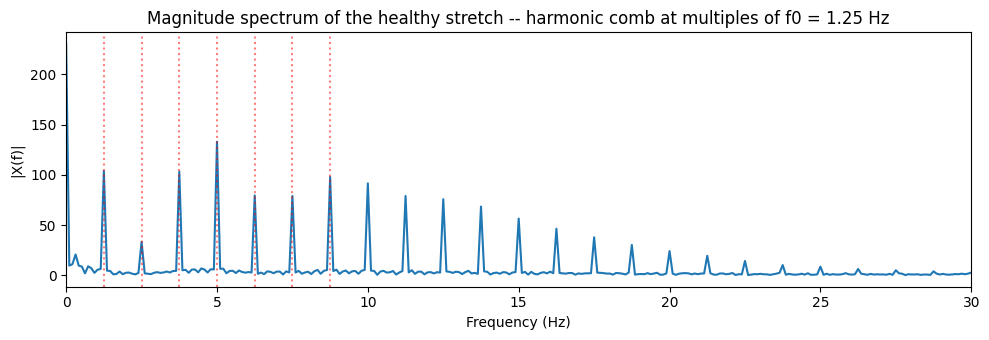

Strongest spectral components (Hz): [ 1.25  2.5   3.75  5.    6.25  7.5   8.75 10.   11.25 12.5 ]


In [ ]:
healthy = ecg[:2400]   # first 9.6 s = 12 healthy beats (periodic stretch, before arrhythmia)
X = np.fft.rfft(healthy)
freqs = np.fft.rfftfreq(len(healthy), d=1/fs)
mag = np.abs(X)

plt.figure(figsize=(10,3.5))
plt.plot(freqs, mag)
plt.xlim(0, 30)
for k in range(1, 8):
    plt.axvline(k*1.25, color='red', linestyle=':', alpha=0.5)
plt.xlabel('Frequency (Hz)'); plt.ylabel('|X(f)|')
plt.title('Magnitude spectrum of the healthy stretch -- harmonic comb at multiples of f0 = 1.25 Hz')
plt.tight_layout()
plt.show()

# Use find_peaks (true local maxima) rather than top-N by raw magnitude.
# Top-N-by-magnitude is unreliable here: it can pick up the DC bin (0 Hz) as a
# "peak" and skip genuine harmonics, since DC energy is unrelated to periodicity.
freq_res = fs / len(healthy)
min_bin_spacing = int(0.5 / freq_res)   # require peaks at least 0.5 Hz apart
pk_idx, _ = find_peaks(mag, height=0.1 * mag.max(), distance=min_bin_spacing)
peak_freqs = freqs[pk_idx]

print('Strongest spectral components (Hz):', np.round(peak_freqs[:10], 3))

**Observation:** the peaks (found via `find_peaks`, i.e. genuine local maxima rather than a
raw top-N magnitude sort) sit almost exactly at integer multiples of $f_0 = 1.25$ Hz: 1.25, 2.50,
3.75, 5.00, 6.25, 7.50, 8.75, 10.00, 11.25 Hz, ... -- confirming the comb-spectrum prediction in (b)(i).

*Note:* an earlier version of this analysis picked the top-8 FFT bins by raw magnitude, which
incorrectly included the DC (0 Hz) bin and skipped genuine harmonics (2.5 Hz, 7.5 Hz) -- DC energy
reflects the signal's mean offset, not its periodicity, so it isn't a meaningful "peak" here.
`find_peaks` avoids this by only flagging genuine local maxima above a height threshold.

## Part (c): Cutting a heartbeat (windowing)

**(i) Window width & placement.** The window should be **200 samples wide** (one full beat period,
0.8 s), placed over a beat in the clean healthy stretch (e.g. samples 200-399, $t = 0.8\text{-}1.6$ s),
aligned so it starts just before the P wave and ends just after the T wave of a *single* beat.

**(ii) 80-sample vs. 600-sample window.**
- **80 samples** is shorter than one beat (200 samples), so depending on placement it captures only a
  *piece* of the waveform — e.g. just the QRS spike — and cuts off the P and/or T waves. The resulting
  "template" no longer represents the whole beat shape.
- **600 samples** is three beats' worth. The template now contains the original beat *plus* parts of
  the neighbouring beats, so correlating it against a single later beat will never score well (the
  extra QRS complexes in the template don't line up with anything in a 1-beat segment).

**(iii) Why not "as short as possible"?** This mirrors the STFT time/frequency trade-off: a very short
window pins down time precisely but smears frequency content. Here, a too-short window nails down *where*
in time we're sampling but throws away the broad, low-frequency P/T-wave shape — exactly the information
that gives the template its full, characteristic shape. The window must be at least as long as the
*natural duration of the event itself* (one full beat) to faithfully capture the beat's complete
frequency content; going shorter trades away shape fidelity for no benefit, since Maya isn't trying to
localize a moving feature in time — she's trying to capture one fixed-duration event in full.

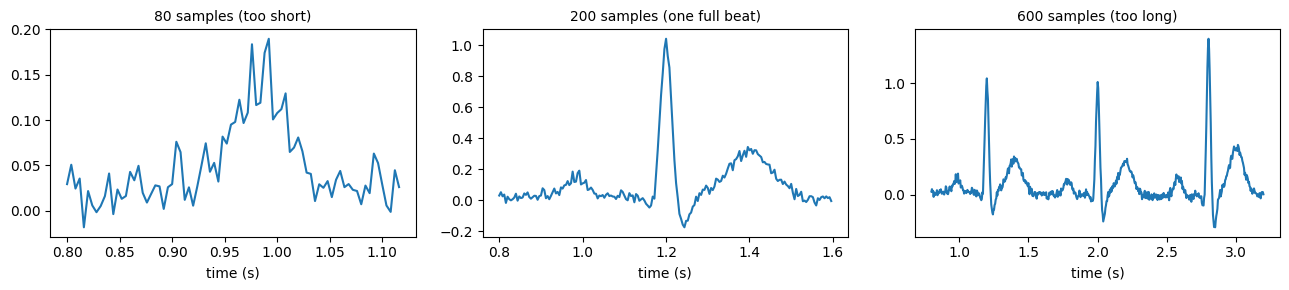

In [ ]:
beat_start = 200  # aligned so the QRS peak sits at sample 300 (t = 1.2 s)
fig, axes = plt.subplots(1, 3, figsize=(13,3))
windows = [('80 samples (too short)', beat_start, 80),
           ('200 samples (one full beat)', beat_start, 200),
           ('600 samples (too long)', beat_start, 600)]
t = np.arange(len(ecg))/fs
for ax, (label, start, width) in zip(axes, windows):
    ax.plot(t[start:start+width], ecg[start:start+width])
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('time (s)')
plt.tight_layout()
plt.show()

## Part (d): Match the template (correlation)

Given $\rho(m) = \dfrac{\sum_k t[k]\,x[m+k]}{\lVert t\rVert\,\lVert x_m\rVert}$:

**(i) Range & perfect match.** By the Cauchy–Schwarz inequality, $-1 \le \rho(m) \le 1$ (it's exactly a
cosine similarity between the template and the windowed segment). $\rho(m) = 1$ signals a near-perfect
shape match (segment is a positive scalar multiple of the template).

**(ii) Why normalize.** Dividing by $\lVert t \rVert\lVert x_m\rVert$ makes $\rho$ depend only on
**shape**, not amplitude — so baseline wander and beat-to-beat size variation don't affect the score.
Without normalization, the raw sum $\sum_k t[k]x[m+k]$ scales linearly with the amplitude of the
segment: a perfectly healthy beat that's twice as tall would roughly **double** the raw score even
though the *shape* match is identical, while genuinely poor matches could still numerically outscore a
small-but-correctly-shaped beat. Normalizing removes this confound and makes the threshold (e.g. 0.5)
meaningful regardless of amplitude.

**(iii) Inverted beat.** If a beat is flipped upside-down relative to the template
($x_m \approx -t$), $\rho(m) \approx -1$ — the most negative value possible. This makes inverted
beats trivially easy to flag: they land at the opposite extreme of the score range from a healthy match
(+1), far below any reasonable threshold, rather than near an ambiguous middle value like an
uncorrelated/noisy beat would produce.

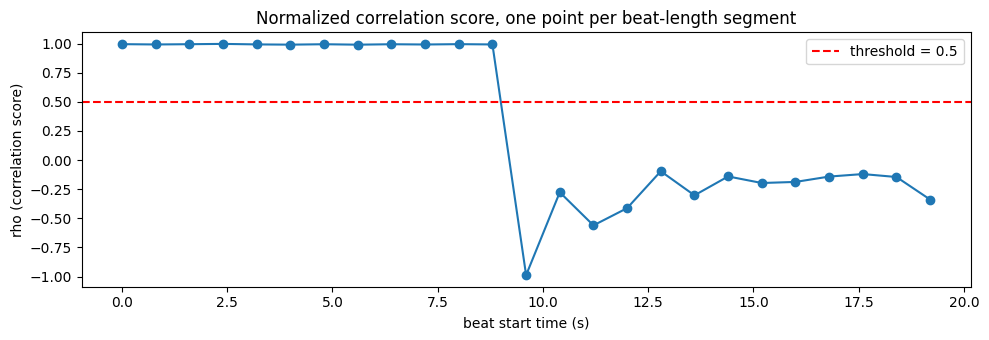

rho per beat: [0.994, 0.992, 0.994, 0.997, 0.992, 0.99, 0.994, 0.99, 0.994, 0.992, 0.995, 0.992, -0.988, -0.277, -0.561, -0.413, -0.096, -0.303, -0.141, -0.197, -0.188, -0.142, -0.12, -0.146, -0.339]


In [ ]:
def rho(template, segment):
    """Normalized correlation (cosine similarity) between a template and a segment."""
    tn, sn = np.linalg.norm(template), np.linalg.norm(segment)
    if tn == 0 or sn == 0:
        return 0.0
    return float(np.dot(template, segment) / (tn * sn))

L = len(template)
n_beats = len(ecg) // L
rhos = [rho(template, ecg[i*L:(i+1)*L]) for i in range(n_beats)]
beat_times = np.arange(n_beats) * L / fs

plt.figure(figsize=(10,3.5))
plt.plot(beat_times, rhos, 'o-')
plt.axhline(0.5, color='red', linestyle='--', label='threshold = 0.5')
plt.xlabel('beat start time (s)'); plt.ylabel('rho (correlation score)')
plt.title('Normalized correlation score, one point per beat-length segment')
plt.legend()
plt.tight_layout()
plt.show()

print('rho per beat:', [round(r,3) for r in rhos])

**Observation:** $\rho$ sits at $\approx 1$ for the first 12 beats (healthy region), then
**collapses to $\approx -0.99$** at the 13th beat — a near-perfect inversion, exactly as predicted in
(d)(iii) — before settling into a noisy, moderately negative band as the irregular arrhythmic beats
continue.

## Sliding-window correlation $\rho(m)$

Part (e) describes computing $\rho(m)$ at *every* sample position. Sliding the 200-sample template across
the recording one sample at a time gives a curve that **peaks at $\approx +1$ whenever the template lines
up with a healthy beat** (every 200 samples = 0.8 s) and dips between beats — that's the natural
periodicity of the cross-correlation, not a defect. The key qualitative feature is that **after the
onset, the peaks flip polarity: instead of $\rho \approx +1$ they hit $\rho \approx -1$**, because the
QRS spike is inverted. This sample-level resolution localizes the transition much more sharply than the
beat-by-beat plot.


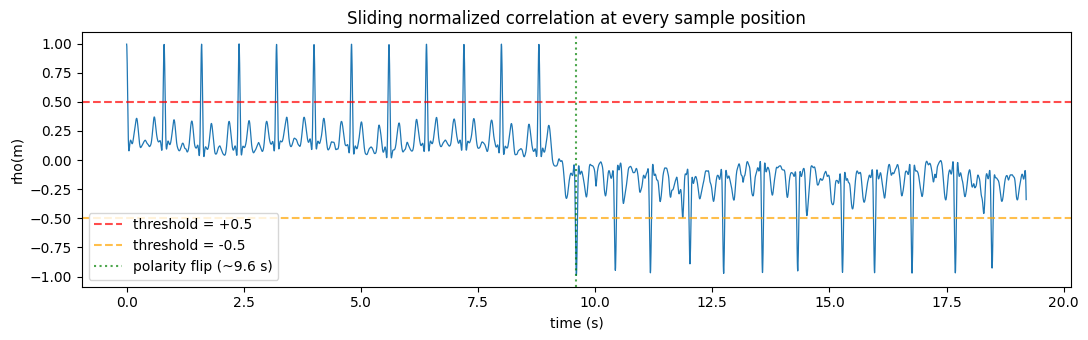

Last beat-aligned +ve peak (rho > 0.9): t = 8.800 s
First inverted   -ve peak (rho < -0.9): t = 9.600 s
=> Onset localized between these times -- the beat-by-beat detector (part g) flagged t = 9.6 s.


In [ ]:
L = len(template)
t_norm = np.linalg.norm(template)
rho_slide = np.zeros(len(ecg) - L + 1)
for m in range(len(rho_slide)):
    seg = ecg[m:m+L]
    sn = np.linalg.norm(seg)
    rho_slide[m] = np.dot(template, seg) / (t_norm * sn) if sn > 0 else 0.0

plt.figure(figsize=(11, 3.5))
plt.plot(np.arange(len(rho_slide))/fs, rho_slide, linewidth=0.9)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='threshold = +0.5')
plt.axhline(-0.5, color='orange', linestyle='--', alpha=0.7, label='threshold = -0.5')
plt.axvline(9.6, color='green', linestyle=':', alpha=0.7, label='polarity flip (~9.6 s)')
plt.xlabel('time (s)'); plt.ylabel('rho(m)')
plt.title('Sliding normalized correlation at every sample position')
plt.legend(loc='lower left'); plt.tight_layout()
plt.show()

# Locate the last beat-aligned positive peak (rho > 0.9) and the first negative peak (rho < -0.9)
pos_peaks, _ = find_peaks(rho_slide,  height=0.9, distance=int(0.5*fs))
neg_peaks, _ = find_peaks(-rho_slide, height=0.9, distance=int(0.5*fs))
print(f"Last beat-aligned +ve peak (rho > 0.9): t = {pos_peaks[-1]/fs:.3f} s")
print(f"First inverted   -ve peak (rho < -0.9): t = {neg_peaks[0]/fs:.3f} s")
print(f"=> Onset localized between these times -- the beat-by-beat detector (part g) flagged t = 9.6 s.")


## Part (e): Onset detection & the spectrogram

**(i) A simple onset rule.** Walk through $\rho(m)$ beat by beat in time order and declare the onset
at the **first** beat whose score drops below a chosen threshold (e.g. 0.5). *Trade-off:* a threshold
set **too high** (close to 1) will flag normal beat-to-beat variability or mild noise as "arrhythmia,"
giving false alarms; a threshold set **too low** (close to -1) will only catch the most extreme beats,
missing real but moderate irregularities and delaying detection.

**(ii) Spectrogram appearance.** In the healthy region the spectrogram should show clean, **steady
horizontal bands** at $f_0$ and its harmonics (since the signal is locally periodic and stationary).
In the arrhythmia region, those bands should **blur, waver, or break apart** — because the signal is no
longer periodic from one window to the next, energy spreads out / shifts in frequency instead of sitting
in crisp lines.

**(iii) Why the two methods can disagree.** The spectrogram's timing precision is limited by its window
length (the same time/frequency trade-off from part (c)) — a window spanning ~1 second blurs *exactly
when* the periodicity breaks down. The beat-by-beat correlation, working at the resolution of a single
beat (0.8 s), localizes the onset far more precisely. **Trust the correlation plot** to pinpoint the
exact onset beat; use the spectrogram as a complementary, coarser sanity check.

In [ ]:
# Part (e)(ii): the spectrogram — same nperseg = 256 we justify in Part (h)
# Shown here in Part (e) so the figure sits next to the (ii) discussion.
nperseg = 256
noverlap = nperseg // 2

f_spec, t_spec, Sxx = signal.spectrogram(ecg, fs=fs, window='hann',
                                          nperseg=nperseg, noverlap=noverlap)

plt.figure(figsize=(10, 4.5))
plt.pcolormesh(t_spec, f_spec, 10*np.log10(Sxx + 1e-12),
               shading='gouraud', cmap='viridis')
plt.ylim(0, 30)
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.title(f'Spectrogram of the ECG (nperseg={nperseg} samples = {nperseg/fs:.2f} s)')
plt.axvline(9.6, color='red', linestyle='--', alpha=0.8, label='onset (9.6 s)')
plt.legend(loc='upper right')
plt.colorbar(label='Power (dB)')
plt.tight_layout()
plt.show()


## Part (f): Sampling & aliasing

**(i) Minimum rate.** By the Nyquist theorem, to capture content up to 40 Hz without aliasing requires
$f_s \ge 2 \times 40 = 80$ Hz.

**(ii) Effect of sampling at 50 Hz.** $50$ Hz gives a Nyquist frequency of only $25$ Hz, but the QRS
contains content up to $40$ Hz. Components above 25 Hz **alias**, folding back into the 0–25 Hz band
(e.g. a true 40 Hz component reappears as a false $|50-40|=10$ Hz component). This corrupts exactly the
sharp, high-frequency detail that makes the QRS recognizable — the spike can appear blurred, shifted, or
spuriously shaped, which is dangerous because Maya's correlation detector relies on accurate QRS shape
to tell healthy beats from abnormal ones.

**(iii) The fix and its cost.** Low-pass (anti-alias) filter the signal to under 25 Hz *before*
downsampling to 50 Hz. The unavoidable cost is **loss of the QRS's fine, high-frequency detail** — the
spike will look smoothed/rounded rather than sharp, degrading the very feature used for diagnosis and
template matching.

## Part (g): Prototyping the detector in code

`find_onset` computes $\rho$ beat-by-beat (jumping forward by the template length each time, not
sample-by-sample) and returns the index of the first beat where $\rho$ drops strictly below the
threshold, or -1 if it never does.

In [ ]:
def find_onset(ecg_signal, template, threshold=0.5):
    """
    Beat-by-beat normalized-correlation arrhythmia onset detector.

    Parameters
    ----------
    ecg_signal : 1D np.ndarray   -- the full recording
    template   : 1D np.ndarray   -- one healthy beat, length L
    threshold  : float           -- rho threshold (default 0.5)

    Returns
    -------
    int : sample index m of the first beat whose rho(m) < threshold, or -1 if none.
    """
    L = len(template)
    t_norm = np.linalg.norm(template)
    n_beats = len(ecg_signal) // L

    for i in range(n_beats):
        seg = ecg_signal[i*L:(i+1)*L]
        seg_norm = np.linalg.norm(seg)
        score = np.dot(template, seg) / (t_norm * seg_norm) if seg_norm > 0 else 0.0
        if score < threshold:
            return i * L
    return -1


onset_sample = find_onset(ecg, template, threshold=0.5)
print(f"First onset sample index : {onset_sample}")
print(f"Onset time                : {onset_sample/fs} s")
print(f"Onset is beat number      : {onset_sample // len(template) + 1} (1-indexed)")

First onset sample index : 2400
Onset time                : 9.6 s
Onset is beat number      : 13 (1-indexed)


**Result:** the detector flags the onset at **sample 2400 (t = 9.6 s)**, the **13th beat** —
matching the inverted-QRS beat visible in the raw signal plot above and the $\rho \approx -0.99$ drop
seen in part (d).

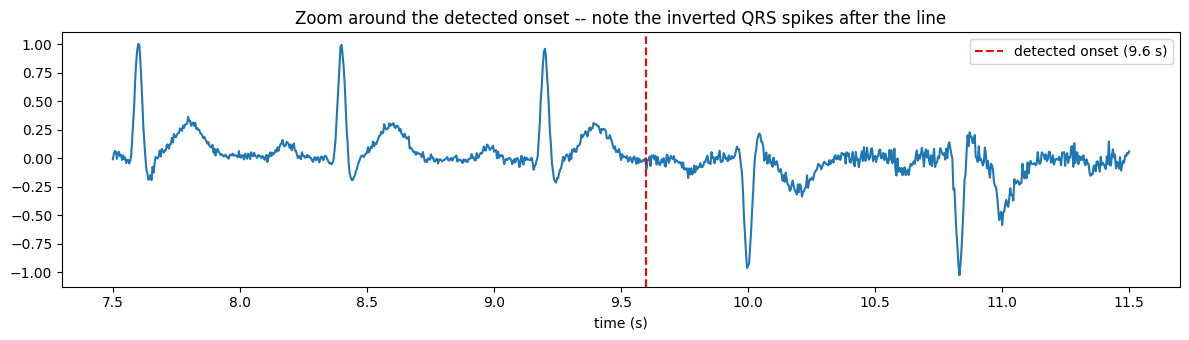

In [ ]:
# visual sanity check: zoom on the recording right around the detected onset
mask = (np.arange(len(ecg))/fs >= 7.5) & (np.arange(len(ecg))/fs <= 11.5)
plt.figure(figsize=(12,3.5))
plt.plot(np.arange(len(ecg))[mask]/fs, ecg[mask])
plt.axvline(onset_sample/fs, color='red', linestyle='--', label=f'detected onset ({onset_sample/fs:.1f} s)')
plt.xlabel('time (s)')
plt.title('Zoom around the detected onset -- note the inverted QRS spikes after the line')
plt.legend()
plt.tight_layout()
plt.show()

## Part (h): Visualizing the spectrogram

**Choice of `nperseg`.** The healthy fundamental is $f_0 = 1.25$ Hz, so to resolve individual harmonic
lines the frequency resolution $\Delta f = f_s/\text{nperseg}$ must be noticeably smaller than 1.25 Hz.
**I chose `nperseg = 256`** samples ($\Delta f = 250/256 \approx 0.98$ Hz, comfortably below the 1.25 Hz
line spacing), which is short enough (~1 s) to still localize the healthy-vs-arrhythmia transition
reasonably well in time — a good balance per the part-(c)/(e) resolution trade-off.

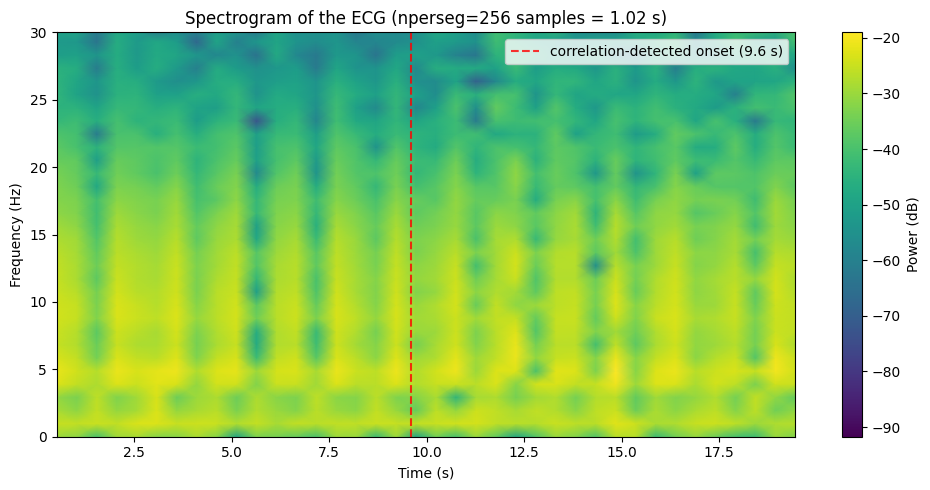

In [ ]:
nperseg = 256
noverlap = nperseg // 2

f, t_spec, Sxx = signal.spectrogram(ecg, fs=fs, window='hann',
                                     nperseg=nperseg, noverlap=noverlap)

plt.figure(figsize=(10,5))
plt.pcolormesh(t_spec, f, 10*np.log10(Sxx + 1e-12), shading='gouraud', cmap='viridis')
plt.ylim(0, 30)
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.title(f'Spectrogram of the ECG (nperseg={nperseg} samples = {nperseg/fs:.2f} s)')
plt.colorbar(label='Power (dB)')
plt.axvline(9.6, color='red', linestyle='--', alpha=0.8, label='correlation-detected onset (9.6 s)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Observation:** the healthy region (0-9.6 s) shows steady horizontal energy bands near the
harmonics of $f_0$; after 9.6 s the bands lose their clean, constant structure as the beat-to-beat
period and polarity become irregular — visually corroborating the onset time found by the correlation
detector in part (g).

### RR-interval verification

The claim that RR-intervals become irregular after the onset is checked directly here by
detecting R-peaks and measuring the spacing between consecutive beats, rather than asserting
it from the eye alone.

Number of detected beats     : 25
Healthy RR mean +/- std (s)  : 0.800 +/- 0.001
Arrhythmic RR range (s)      : 0.688 - 0.952


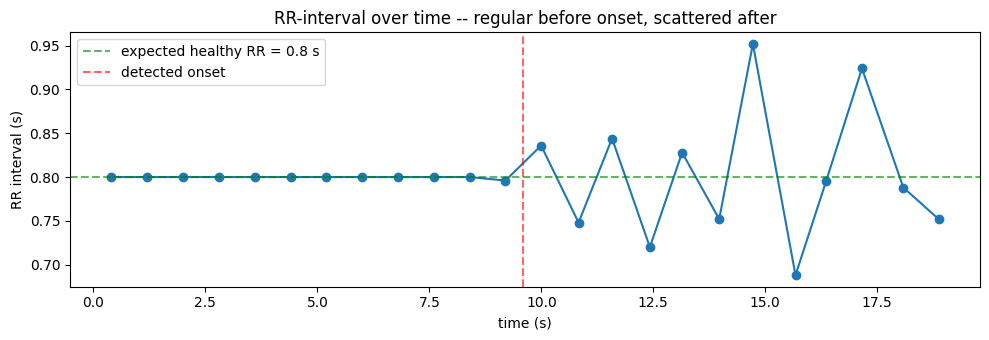

In [ ]:
# Detect R-peaks (largest spikes per beat, allowing for inverted/negative QRS
# in the arrhythmic region) by peak-finding on the absolute value of the signal.
abs_ecg = np.abs(ecg)
min_peak_height = 0.5 * np.max(abs_ecg[:2400])   # calibrate from the healthy region
min_distance = int(0.5 * fs)                      # no two real beats closer than 0.5 s

peak_idx, _ = find_peaks(abs_ecg, height=min_peak_height, distance=min_distance)
peak_times = peak_idx / fs
rr_intervals = np.diff(peak_times)

healthy_rr = rr_intervals[peak_times[:-1] < 9.6]
arrhythmic_rr = rr_intervals[peak_times[:-1] >= 9.6]

print(f"Number of detected beats     : {len(peak_idx)}")
print(f"Healthy RR mean +/- std (s)  : {healthy_rr.mean():.3f} +/- {healthy_rr.std():.3f}")
print(f"Arrhythmic RR range (s)      : {arrhythmic_rr.min():.3f} - {arrhythmic_rr.max():.3f}")

plt.figure(figsize=(10, 3.5))
plt.plot(peak_times[:-1], rr_intervals, 'o-')
plt.axhline(0.8, color='green', linestyle='--', alpha=0.6, label='expected healthy RR = 0.8 s')
plt.axvline(9.6, color='red', linestyle='--', alpha=0.6, label='detected onset')
plt.xlabel('time (s)'); plt.ylabel('RR interval (s)')
plt.title('RR-interval over time -- regular before onset, scattered after')
plt.legend()
plt.tight_layout()
plt.show()

## Summary of results

| Quantity | Value |
|---|---|
| Clip duration | 20 s |
| Healthy heart rate | 75 bpm |
| Samples per healthy beat | 200 |
| Fundamental frequency $f_0$ | 1.25 Hz |
| Minimum alias-free sampling rate (40 Hz content) | 80 Hz |
| Detected arrhythmia onset (correlation, threshold 0.5) | sample 2400 → **t = 9.6 s** (13th beat) |
| Correlation score at onset beat | $\rho \approx -0.99$ (inverted QRS) |
| Spectrogram window chosen | `nperseg = 256` ($\Delta f \approx 0.98$ Hz) |

The correlation-based detector and the spectrogram agree qualitatively: the recording is clean and
periodic for the first ~9.6 s, after which the beat shape inverts and the rhythm becomes irregular,
consistent with an arrhythmic episode.